# p3 — Post-Analysis & Figure Generation

**Purpose:** Load the fitted IRT parameters from `data_irt/`, compute all statistics reported in the paper, and generate the four publication figures.

**Figures produced:**
| # | File | Description |
|---|------|-------------|
| 1 | `fig1_rho_heatmaps.pdf` | Spearman ρ matrices of subtask rank orderings (BBH & MATH, cohort & arch) |
| 2 | `fig2_dendrograms.pdf` | Architecture clustering by ranking similarity |
| 3 | `fig3_trajectories.pdf` | Discrimination rank trajectories per architecture across cohorts |
| 4 | `fig4_typology.pdf` | Subtask typology — temporal vs architecture rank instability |

Each figure function accepts a `save` flag: `save=False` renders inline; `save=True` writes a PDF and closes the figure.

**Input:** `data_irt/{bbh,math}/{bm}_discriminations_2pl.csv`, `data_irt/{bbh,math}/{bm}_difficulties_2pl.csv`  
**Output:** `fig1_rho_heatmaps.pdf`, `fig2_dendrograms.pdf`, `fig3_trajectories.pdf`, `fig4_typology.pdf`

## Imports, Style & Constants

Global matplotlib settings follow NeurIPS style (Times New Roman, 8 pt body, PDF-embeddable fonts via `fonttype=42`). Colour constants are reused across all four figures for visual consistency.

In [18]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import spearmanr
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform
%matplotlib inline

# NeurIPS style settings
plt.rcParams.update({
    'font.size': 8,
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'axes.titlesize': 8,
    'axes.labelsize': 8,
    'xtick.labelsize': 6,
    'ytick.labelsize': 6,
    'legend.fontsize': 7,
    'figure.dpi': 150,
    'savefig.dpi': 300,  # Higher for publication
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05,
    'pdf.fonttype': 42,  # Ensure text is editable
    'ps.fonttype': 42,
})

COHORT_ORDER = ['Q2-2024', 'Q3-2024', 'Q4-2024', 'Q1-2025']
COH_LABELS   = ['Q2-24',  'Q3-24',   'Q4-24',   'Q1-25']
ARCHS        = ['Gemma2ForCausalLM', 'LlamaForCausalLM',
                'MistralForCausalLM', 'Qwen2ForCausalLM']
ARCH_SHORT   = ['Gemma2', 'Llama', 'Mistral', 'Qwen2']

# Colour palette
GRAY   = '#444441'; MID   = '#B4B2A9'; LIGHT = '#F1EFE8'
PURPLE = '#534AB7'; TEAL  = '#0F6E56'; AMBER = '#854F0B'
RED    = '#A32D2D'; BLUE  = '#1A5FA5'

## Core Analysis Functions

### `spearman_rho_matrix`
For each pair of groups (cohorts or architectures), computes the Spearman ρ between their subtask rank orderings. A ρ near 1.0 means the two groups agree on which subtasks are hardest/easiest; a lower ρ reveals rank disagreement.

### `rank_variance`
For each subtask, computes the standard deviation of its rank across groups. High variance flags subtasks whose relative difficulty or discrimination shifts substantially between cohorts or architecture families — the primary instability signal in the paper.

In [19]:
def spearman_rho_matrix(df: pd.DataFrame, cols: list,
                        groups: list, group_col: str) -> np.ndarray:
    """
    Compute the (len(groups) x len(groups)) Spearman rho matrix
    of subtask rank orderings, one per group.

    Parameters
    ----------
    df        : DataFrame containing group_col and cols
    cols      : list of subtask column names
    groups    : ordered list of group values (cohorts or arch names)
    group_col : column name for grouping ('cohort' or 'arch')

    Returns
    -------
    ndarray of shape (n_groups, n_groups) with rho values
    """
    means = df.groupby(group_col)[cols].mean().loc[groups]
    ranks = means.rank(axis=1, ascending=False)
    n = len(groups)
    mat = np.zeros((n, n))
    for i, g1 in enumerate(groups):
        for j, g2 in enumerate(groups):
            rho, _ = spearmanr(ranks.loc[g1], ranks.loc[g2])
            mat[i, j] = rho
    return mat


def rank_variance(df: pd.DataFrame, cols: list,
                  groups: list, group_col: str) -> pd.Series:
    """
    Compute per-subtask standard deviation of rank across groups.

    Returns pd.Series indexed by subtask name.
    """
    means = df.groupby(group_col)[cols].mean().loc[groups]
    ranks = means.rank(axis=1, ascending=False)
    return ranks.std()

## Data Loading

`load_benchmark` reads the two CSVs for one benchmark and separates subtask columns from the `cohort`/`arch` label columns.

> **Note:** GPQA and MuSR are intentionally excluded from `load_all` — both have only 3 subtask groups, which is too few for reliable Spearman rank-order analysis.

In [20]:
def load_benchmark(data_dir: str, bm: str) -> dict:
    """
    Load discrimination and difficulty CSVs for one benchmark.

    Returns a dict with keys:
        disc       - raw DataFrame
        diff       - raw DataFrame
        disc_cols  - list of subtask column names (discrimination)
        diff_cols  - list of subtask column names (difficulty)
        n_subtasks - int
    """
    disc = pd.read_csv(os.path.join(data_dir, f'{bm}_discriminations_2pl.csv'))
    diff = pd.read_csv(os.path.join(data_dir, f'{bm}_difficulties_2pl.csv'))
    disc_cols = [c for c in disc.columns if c not in ('cohort', 'arch')]
    diff_cols = [c for c in diff.columns if c not in ('cohort', 'arch')]
    return dict(disc=disc, diff=diff,
                disc_cols=disc_cols, diff_cols=diff_cols,
                n_subtasks=len(disc_cols))


def load_all() -> dict:
    """Load all four benchmarks; return nested dict keyed by benchmark name."""
    benchmarks = ['bbh', 'math', 'gpqa', 'musr']
    
    return {
        'bbh': load_benchmark('../data_irt/bbh', 'bbh'),
        'math': load_benchmark('../data_irt/math', 'math')
    }

In [21]:
data = load_all()

## Compute All Results

`compute_results` runs every analysis in one pass over the loaded benchmarks and stores the outputs in a nested dict. Benchmarks with fewer than 4 subtasks are skipped (GPQA, MuSR).

Pre-computed values stored per benchmark:
- `rho_disc_coh` / `rho_diff_coh` — Spearman ρ matrices across cohorts
- `rho_disc_arc` / `rho_diff_arc` — Spearman ρ matrices across architectures
- `lr_disc` / `lr_diff` — long-range ρ (Q2-2024 vs Q1-2025)
- `delta_rho` — element-wise difference ρ_diff − ρ_disc (dissociation signal)
- `mean_delta_per_arch` — mean Δρ per architecture (averaged over all other archs)
- `coh_var_disc` / `coh_var_diff` — per-subtask rank variance across cohorts
- `arc_var_disc` / `arc_var_diff` — per-subtask rank variance across architectures

In [22]:
def compute_results(data: dict) -> dict:
    """
    Run all analyses for every benchmark.
    Returns nested dict with precomputed matrices and series.
    Only computes rho/variance for benchmarks with n_subtasks > 3.
    """
    results = {}
    for bm, d in data.items():
        nc = d['n_subtasks']
        res = {'n_subtasks': nc}
        if nc > 3:
            res['rho_disc_coh'] = spearman_rho_matrix(
                d['disc'], d['disc_cols'], COHORT_ORDER, 'cohort')
            res['rho_diff_coh'] = spearman_rho_matrix(
                d['diff'], d['diff_cols'], COHORT_ORDER, 'cohort')
            res['rho_disc_arc'] = spearman_rho_matrix(
                d['disc'], d['disc_cols'], ARCHS, 'arch')
            res['rho_diff_arc'] = spearman_rho_matrix(
                d['diff'], d['diff_cols'], ARCHS, 'arch')
            res['lr_disc'] = res['rho_disc_coh'][0, 3]   # Q2-2024 vs Q1-2025
            res['lr_diff'] = res['rho_diff_coh'][0, 3]
            res['delta_rho'] = res['rho_diff_arc'] - res['rho_disc_arc']
            res['mean_delta_per_arch'] = [
                np.mean([res['delta_rho'][i, j] for j in range(4) if j != i])
                for i in range(4)
            ]
            res['coh_var_disc'] = rank_variance(
                d['disc'], d['disc_cols'], COHORT_ORDER, 'cohort')
            res['coh_var_diff'] = rank_variance(
                d['diff'], d['diff_cols'], COHORT_ORDER, 'cohort')
            res['arc_var_disc'] = rank_variance(
                d['disc'], d['disc_cols'], ARCHS, 'arch')
            res['arc_var_diff'] = rank_variance(
                d['diff'], d['diff_cols'], ARCHS, 'arch')
        results[bm] = res
    return results

In [23]:
results = compute_results(data)

## Figure 1 — Spearman ρ Heatmaps

A 2×4 grid of heatmaps showing how consistently subtask rank orderings are preserved:
- **Rows:** BBH (top), MATH-Hard (bottom)
- **Columns 1–2:** ρ across cohorts for difficulty and discrimination
- **Columns 3–4:** ρ across architectures for difficulty and discrimination

**Reading the heatmap:** A cell value of 1.0 means the two groups rank subtasks identically. A lower value in the discrimination columns vs the difficulty columns is the central finding — difficulty rankings are stable, discrimination rankings are not.

In [24]:
def draw_heatmap(ax, mat: np.ndarray, xlabels: list, ylabels: list,
                 title: str, cmap: str, vmin: float, vmax: float,
                 fontsize: float = 7.0):
    """Draw a square heatmap with annotated cell values."""
    im = ax.imshow(mat, cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')
    ax.set_xticks(range(len(xlabels)))
    ax.set_xticklabels(xlabels, fontsize=fontsize - 0.5, rotation=30, ha='right')
    ax.set_yticks(range(len(ylabels)))
    ax.set_yticklabels(ylabels, fontsize=fontsize - 0.5)
    mid = (vmin + vmax) / 2 + (vmax - vmin) / 10
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            color = 'white' if mat[i, j] >= mid else GRAY
            ax.text(j, i, f'{mat[i, j]:.2f}', ha='center', va='center',
                    fontsize=fontsize - 1.5, color=color)
    ax.set_title(title, fontsize=fontsize, fontweight='bold', color=GRAY, pad=4)
    return im

def fig1_rho_heatmaps(results: dict, save=False):
    """
    4×2 heatmap grid showing Spearman rho matrices for
    BBH (top row) and MATH (bottom row), cohort (cols 1-2)
    and architecture (cols 3-4), difficulty vs discrimination.
    """
    fig, axes = plt.subplots(2, 4, figsize=(8.5, 4.5))
    fig.subplots_adjust(wspace=0.38, hspace=0.55)

    # Row 0: BBH
    draw_heatmap(axes[0, 0], results['bbh']['rho_diff_coh'],
                 COH_LABELS, COH_LABELS,
                 'BBH — Difficulty (cohort)',       'RdYlGn', 0.85, 1.0)
    draw_heatmap(axes[0, 1], results['bbh']['rho_disc_coh'],
                 COH_LABELS, COH_LABELS,
                 'BBH — Discrimination (cohort)',   'RdYlGn', 0.60, 1.0)
    draw_heatmap(axes[0, 2], results['bbh']['rho_diff_arc'],
                 ARCH_SHORT, ARCH_SHORT,
                 'BBH — Difficulty (arch)',         'RdYlGn', 0.85, 1.0)
    draw_heatmap(axes[0, 3], results['bbh']['rho_disc_arc'],
                 ARCH_SHORT, ARCH_SHORT,
                 'BBH — Discrimination (arch)',     'RdYlGn', 0.60, 1.0)

    # Row 1: MATH
    draw_heatmap(axes[1, 0], results['math']['rho_diff_coh'],
                 COH_LABELS, COH_LABELS,
                 'MATH — Difficulty (cohort)',      'RdYlGn', 0.85, 1.0)
    draw_heatmap(axes[1, 1], results['math']['rho_disc_coh'],
                 COH_LABELS, COH_LABELS,
                 'MATH — Discrimination (cohort)',  'RdYlGn', 0.60, 1.0)
    draw_heatmap(axes[1, 2], results['math']['rho_diff_arc'],
                 ARCH_SHORT, ARCH_SHORT,
                 'MATH — Difficulty (arch)',        'RdYlGn', 0.85, 1.0)
    draw_heatmap(axes[1, 3], results['math']['rho_disc_arc'],
                 ARCH_SHORT, ARCH_SHORT,
                 'MATH — Discrimination (arch)',    'RdYlGn', 0.60, 1.0)

    fig.suptitle('Spearman $\\rho$ of subtask rank orderings — BBH vs MATH-HARD',
                 fontsize=9, fontweight='bold', color=GRAY, y=1.01)

    if save:
        path = './fig1_rho_heatmaps.pdf'
        fig.savefig(path, bbox_inches='tight', dpi=300,
                    facecolor='white', edgecolor='none')
        plt.close()
        print(f'Saved {path}')

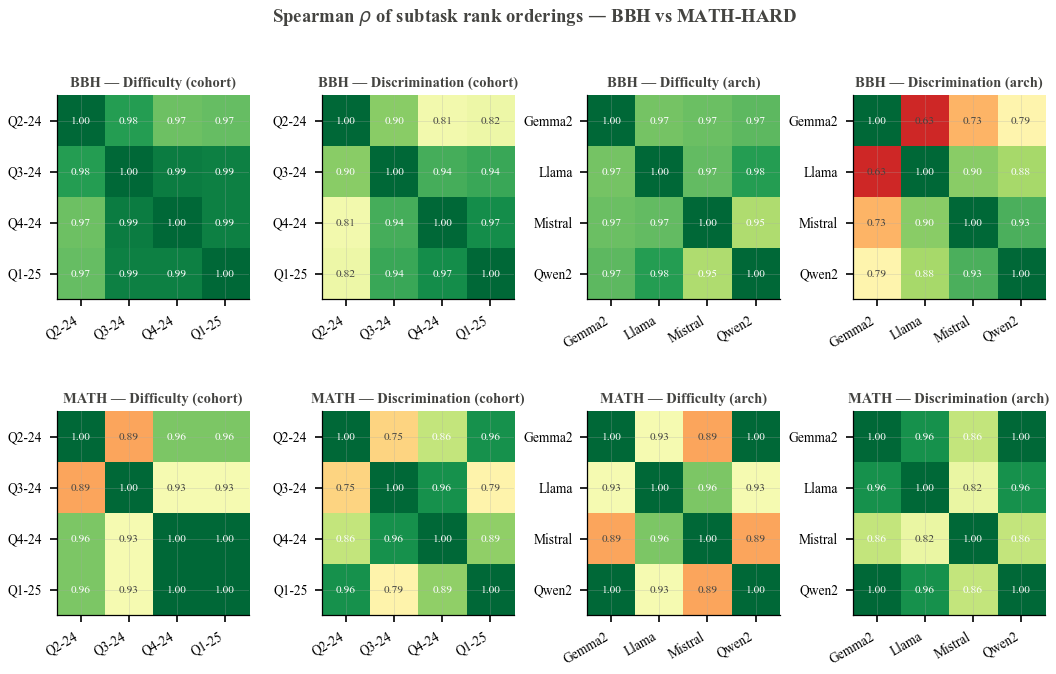

In [25]:
fig1_rho_heatmaps(results, save=False)

## Figure 2 — Architecture Dendrograms

Hierarchical clustering of the four architecture families based on their pairwise Spearman ρ distances (`1 − ρ`). Uses average-linkage clustering.

- **Left column:** difficulty rankings — architectures cluster tightly, confirming difficulty is architecture-invariant
- **Right column:** discrimination rankings — looser clustering reveals architecture-specific sensitivity in how well subtasks differentiate strong from weak models

In [26]:
def draw_dendrogram(ax, rho_mat: np.ndarray, labels: list,
                    title: str, color: str):
    """Draw hierarchical clustering dendrogram from a rho matrix."""
    dist = np.clip(1 - rho_mat, 0, None)
    np.fill_diagonal(dist, 0)
    Z = linkage(squareform(dist), method='average')
    dendrogram(Z, labels=labels, ax=ax, color_threshold=0,
               above_threshold_color=color, leaf_font_size=8)
    ax.set_ylabel('Distance (1−ρ)', fontsize=7)
    ax.set_title(title, fontsize=8, fontweight='bold', color=GRAY)
    ax.tick_params(axis='x', labelsize=7)



def fig2_dendrograms(results: dict, save=False):
    """
    2×2 dendrogram grid: BBH (top row) and MATH (bottom row),
    difficulty (left) and discrimination (right).
    """
    fig, axes = plt.subplots(2, 2, figsize=(7.5, 5.5))
    fig.subplots_adjust(wspace=0.35, hspace=0.55)

    draw_dendrogram(axes[0, 0], results['bbh']['rho_diff_arc'],
                    ARCH_SHORT, 'BBH — Difficulty', TEAL)
    draw_dendrogram(axes[0, 1], results['bbh']['rho_disc_arc'],
                    ARCH_SHORT, 'BBH — Discrimination', PURPLE)

    draw_dendrogram(axes[1, 0], results['math']['rho_diff_arc'],
                    ARCH_SHORT, 'MATH-HARD — Difficulty', TEAL)
    draw_dendrogram(axes[1, 1], results['math']['rho_disc_arc'],
                    ARCH_SHORT, 'MATH-HARD — Discrimination', BLUE)

    fig.suptitle('Architecture clustering by ranking similarity',
                 fontsize=9, fontweight='bold', color=GRAY)
    
    if save:
        path = './fig2_dendrograms.pdf'
        fig.savefig(path, bbox_inches='tight', dpi=150)
        plt.close()
        print(f'Saved {path}')

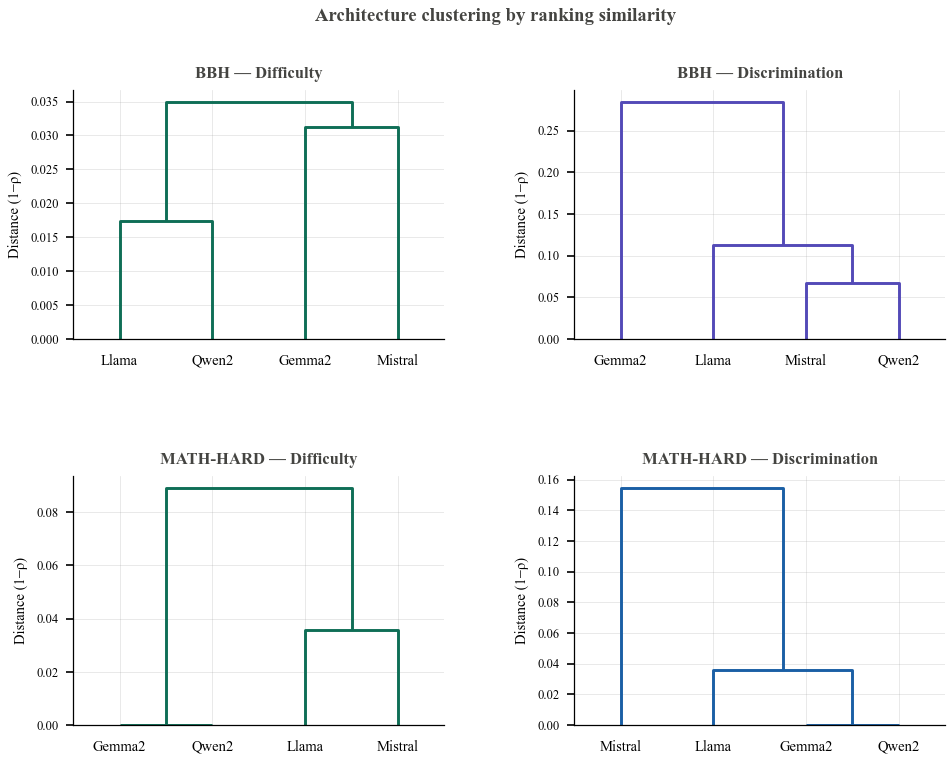

In [27]:
fig2_dendrograms(results, save=False)

## Figure 3 — Discrimination Rank Trajectories

A 4-row × 2-column figure. Each row is one architecture family; left column is BBH, right is MATH-Hard.

Each line is one subtask. The y-axis is its discrimination rank within that cohort (rank 1 = highest discrimination). Highlighted lines are the **most unstable** (largest rank variance across cohorts) and **most stable** subtasks *for that specific architecture*, so arch-specific instability patterns are visible.

> **Note:** This cell overrides the global `rcParams` with a finer NeurIPS-tuned style and also redefines some colour constants for this figure's specific palette. The global constants `PURPLE`, `RED`, and `LIGHT` from the first cell remain available for figures 1, 2, and 4.

In [28]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# ---------------------------------------------------------------------------
# Style — NeurIPS-compatible
# ---------------------------------------------------------------------------
mpl.rcParams.update({
    "font.family":       "serif",
    "font.serif":        ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size":         8,
    "axes.titlesize":    8,
    "axes.labelsize":    7,
    "xtick.labelsize":   7,
    "ytick.labelsize":   7,
    "legend.fontsize":   6.5,
    "axes.linewidth":    0.6,
    "lines.linewidth":   1.4,
    "axes.grid":         True,
    "grid.linewidth":    0.35,
    "grid.alpha":        0.35,
    "grid.color":        "#aaaaaa",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "pdf.fonttype":      42,
    "ps.fonttype":       42,
    "savefig.dpi":       300,
    "savefig.bbox":      "tight",
})

# ---------------------------------------------------------------------------
# Palette
# ---------------------------------------------------------------------------
AMBER  = "#D85A30"   # BBH unstable
BLUE   = "#185FA5"   # MATH unstable
TEAL   = "#1D9E75"   # stable (both panels)
MID    = "#B4B2A9"   # other (ghost lines)
GRAY   = "#444441"   # titles

# ---------------------------------------------------------------------------
# Ordering & labels
# ---------------------------------------------------------------------------
COHORT_ORDER = ["Q2-2024", "Q3-2024", "Q4-2024", "Q1-2025"]
COH_LABELS   = ["Q2 '24", "Q3 '24", "Q4 '24", "Q1 '25"]

ARCH_ORDER  = [
    "LlamaForCausalLM",
    "Qwen2ForCausalLM",
    "MistralForCausalLM",
    "Gemma2ForCausalLM",
]
ARCH_LABELS = ["Llama", "Qwen2", "Mistral", "Gemma2"]

SHORT_BBH = {
    'boolean_expressions':   'Boolean Expressions',
    'causal_judgement':       'Causal Judgement',
    'date_understanding':     'Date Understanding',
    'disambiguation_qa':      'Disambiguation QA',
    'formal_fallacies':       'Formal Fallacies',
    'geometric_shapes':       'Geometric Shapes',
    'hyperbaton':             'Hyperbaton',
    'logical_deduction_5obj': 'Logical Ded. (5-obj)',
    'logical_deduction_7obj': 'Logical Ded. (7-obj)',
    'logical_deduction_3obj': 'Logical Ded. (3-obj)',
    'movie_recommendation':   'Movie Recommendation',
    'navigate':               'Navigate',
    'object_counting':        'Object Counting',
    'penguins_in_table':      'Penguins in Table',
    'reasoning_colored_obj':  'Reasoning Col. Objects',
    'ruin_names':             'Ruin Names',
    'salient_translation':    'Salient Translation',
    'snarks':                 'Snarks',
    'sports_understanding':   'Sports Understanding',
    'temporal_sequences':     'Temporal Sequences',
    'tracking_5obj':          'Tracking (5-obj)',
    'tracking_7obj':          'Tracking (7-obj)',
    'tracking_3obj':          'Tracking (3-obj)',
    'web_of_lies':            'Web of Lies',
}

SHORT_MATH = {
    'algebra':              'Algebra',
    'counting_and_prob':    'Counting & Probability',
    'geometry':             'Geometry',
    'intermediate_algebra': 'Intermediate Algebra',
    'num_theory':           'Number Theory',
    'prealgebra':           'Pre-Algebra',
    'precalculus':          'Pre-Calculus',
}


# ---------------------------------------------------------------------------
# Per-arch rank and variance helpers
# ---------------------------------------------------------------------------

def arch_ranks(df: pd.DataFrame, cols: list, arch: str) -> pd.DataFrame:
    """Return rank DataFrame [cohort × subtask] for one architecture.
    Each (arch, cohort) is one row — no aggregation needed."""
    sub = df[df['arch'] == arch].set_index('cohort')[cols].reindex(COHORT_ORDER)
    return sub.rank(axis=1, ascending=False)


def arch_rank_variance(ranks: pd.DataFrame) -> pd.Series:
    """Variance of each subtask's rank across cohorts — instability proxy."""
    return ranks.var(axis=0)


# ---------------------------------------------------------------------------
# Single-arch panel draw
# ---------------------------------------------------------------------------

def draw_trajectories(ax, df: pd.DataFrame, cols: list,
                      rank_var: pd.Series, top_n: int,
                      short_map: dict, title: str,
                      c_unstable: str, c_stable: str,
                      arch: str):
    """
    Draw discrimination rank trajectory lines for one architecture across cohorts.
    Highlights top_n most unstable and top 3 most stable subtasks *for this arch*.

    Parameters
    ----------
    ax          : Axes to draw on
    df          : full discriminations DataFrame (all archs)
    cols        : subtask column names
    rank_var    : per-subtask rank variance Series for this arch
    top_n       : number of most-unstable subtasks to highlight
    short_map   : column → display label
    title       : panel title
    c_unstable  : colour for unstable series
    c_stable    : colour for stable series
    arch        : architecture name string (used to filter df)
    """
    ranks = arch_ranks(df, cols, arch)

    top_unstable = rank_var.nlargest(top_n).index.tolist()
    top_stable   = rank_var.nsmallest(min(3, len(cols))).index.tolist()
    x = list(range(len(COHORT_ORDER)))

    for s in cols:
        y = ranks[s].values
        if s in top_unstable:
            lw, alpha, color, zorder, dash = 1.6, 0.95, c_unstable, 5, (4, 2)
        elif s in top_stable:
            lw, alpha, color, zorder, dash = 1.6, 0.95, c_stable,   5, ()
        else:
            lw, alpha, color, zorder, dash = 0.5, 0.22, MID,        2, (2, 3)

        line, = ax.plot(x, y, color=color, lw=lw, alpha=alpha, zorder=zorder,
                        solid_capstyle='round', solid_joinstyle='round')
        if dash:
            line.set_dashes(dash)

        if s in top_unstable or s in top_stable:
            ax.scatter([x[-1]], [y[-1]], color=color, s=16, zorder=11,
                       edgecolors='white', linewidths=0.5)
            ax.annotate(
                short_map.get(s, s),
                xy=(x[-1], y[-1]),
                xytext=(x[-1] + 0.08, y[-1]),
                fontsize=5.5, color=color, va='center', ha='left',
                annotation_clip=False, zorder=10,
            )

    ax.set_xticks(x)
    ax.set_xticklabels(COH_LABELS)
    ax.set_ylabel('Discrimination rank\n(1 = highest)', labelpad=4)
    ax.set_xlim(-0.25, len(COHORT_ORDER) - 0.5)
    ax.set_ylim(0.3, len(cols) + 0.5)
    ax.invert_yaxis()
    ax.set_title(title, loc='left', fontweight='bold', color=GRAY, pad=5)

    handles = [
        Line2D([0], [0], color=c_stable,   lw=1.6,               label='Most stable'),
        Line2D([0], [0], color=c_unstable, lw=1.6, dashes=(4, 2), label='Most unstable'),
        Line2D([0], [0], color=MID,        lw=0.6, dashes=(2, 3),
               alpha=0.7, label='Other'),
    ]
    ax.legend(handles=handles, frameon=True, framealpha=0.9,
              edgecolor='#cccccc', fancybox=False, handlelength=2.4,
              loc='lower left')


# ---------------------------------------------------------------------------
# Figure: 4 arch panels × 2 benchmarks = 4 rows × 2 cols
# ---------------------------------------------------------------------------

def fig3_trajectories(data: dict, results: dict, save=False):
    """
    4-row × 2-col figure. Each row = one architecture family.
    Left column = BBH, right column = MATH.
    Highlights are computed *per architecture* so arch-specific instability
    is visible, enabling arch × cohort interaction inspection.
    """
    n_archs = len(ARCH_ORDER)

    fig, axes = plt.subplots(
        n_archs, 2,
        figsize=(11.0, 5.5 * n_archs / 2),   # ~11 × 11 for 4 archs; scale as needed
        gridspec_kw={'wspace': 0.45, 'hspace': 0.65},
    )

    for row, (arch, arch_label) in enumerate(zip(ARCH_ORDER, ARCH_LABELS)):
        # --- BBH (left column) ---
        bbh_var = arch_rank_variance(
            arch_ranks(data['bbh']['disc'], data['bbh']['disc_cols'], arch)
        )
        draw_trajectories(
            axes[row, 0],
            data['bbh']['disc'], data['bbh']['disc_cols'],
            rank_var=bbh_var, top_n=3,
            short_map=SHORT_BBH,
            title=f'({chr(97 + row*2)}) BBH — {arch_label}',
            c_unstable=AMBER, c_stable=TEAL,
            arch=arch,
        )

        # --- MATH (right column) ---
        math_var = arch_rank_variance(
            arch_ranks(data['math']['disc'], data['math']['disc_cols'], arch)
        )
        draw_trajectories(
            axes[row, 1],
            data['math']['disc'], data['math']['disc_cols'],
            rank_var=math_var, top_n=3,
            short_map=SHORT_MATH,
            title=f'({chr(97 + row*2 + 1)}) MATH-HARD — {arch_label}',
            c_unstable=BLUE, c_stable=TEAL,
            arch=arch,
        )

    fig.suptitle(
        'Discrimination rank trajectories by architecture and cohort',
        fontsize=9, fontweight='bold', color=GRAY, y=1.005,
    )

    if save:
        path = './fig3_trajectories.pdf'
        fig.savefig(path, bbox_inches='tight', dpi=300)
        plt.close()
        print(f'Saved {path}')
    else:
        plt.show()    

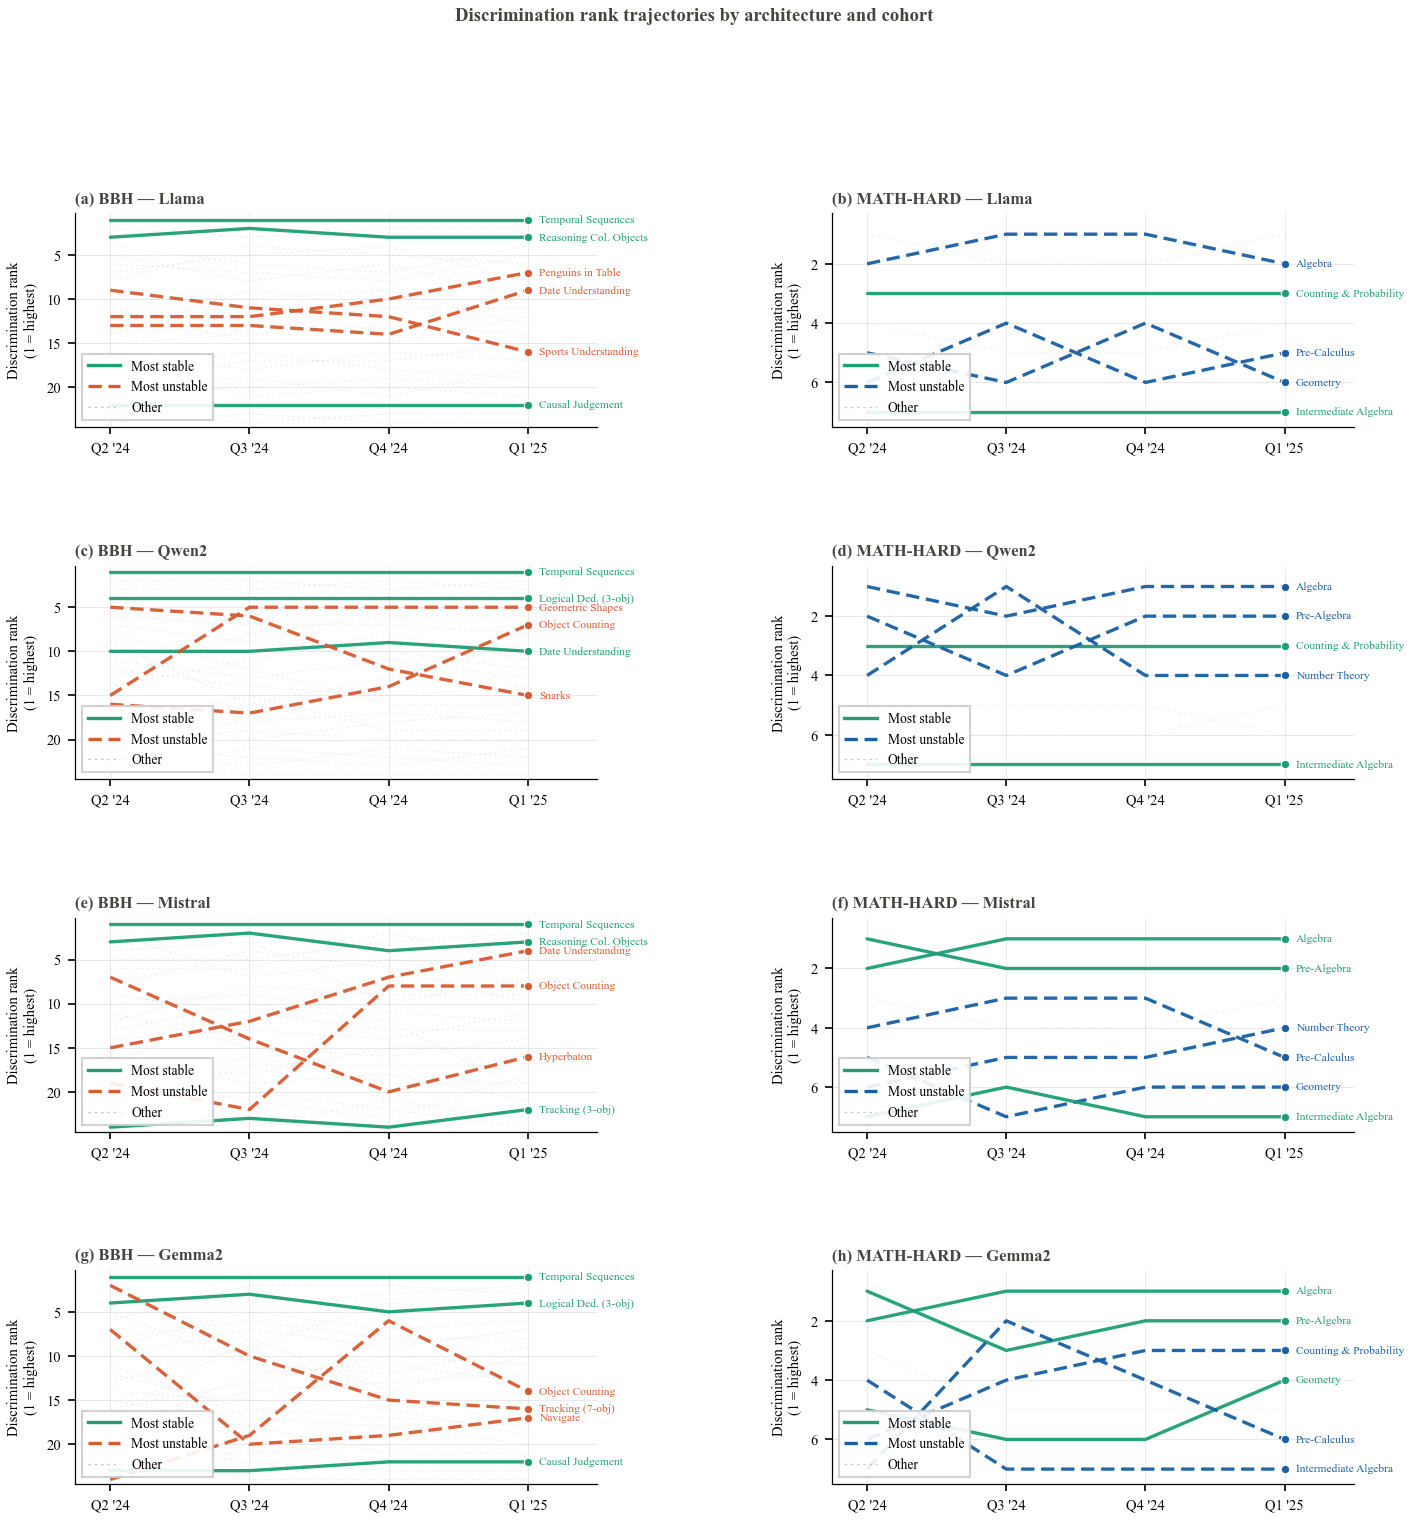

In [29]:
fig3_trajectories(data, results, save=False)

## Figure 4 — Subtask Typology Scatter

Each point is one subtask. The axes measure two independent instability dimensions:
- **x-axis:** temporal rank variance (how much the subtask's discrimination rank shifts across cohorts)
- **y-axis:** cross-architecture rank variance (how much it shifts across Llama / Qwen2 / Mistral / Gemma2)

Median splits define four quadrants:
| Quadrant | Meaning |
|----------|---------|
| **Invariant** (low x, low y) | Stable anchor subtasks — reliable for longitudinal comparison |
| **Temporally unstable** (high x, low y) | Drift is cohort-driven, not architecture-driven |
| **Architecture-sensitive** (low x, high y) | Stable over time but architecture-dependent |
| **Fully unstable** (high x, high y) | Unreliable in both dimensions — poor benchmark items |

Notable subtasks are annotated by name.

In [30]:
def draw_typology(ax, coh_var: pd.Series, arc_var: pd.Series,
                  short_map: dict, title: str, notable: list):
    """
    Draw 2D typology scatter: temporal rank variance (x) vs
    cross-architecture rank variance (y).  Four quadrants defined
    by median splits.
    """
    med_x = coh_var.median()
    med_y = arc_var.median()
    ax.axvline(med_x, color=MID, lw=0.7, ls='--', alpha=0.5)
    ax.axhline(med_y, color=MID, lw=0.7, ls='--', alpha=0.5)

    quad_labels = [
        (med_x * 0.35, med_y * 0.35, 'Invariant\n(anchor)', TEAL),
        (med_x * 1.70, med_y * 0.35, 'Temp.\nunstable',     AMBER),
        (med_x * 0.35, med_y * 1.70, 'Arch.\nsensitive',    PURPLE),
        (med_x * 1.70, med_y * 1.70, 'Fully\nunstable',     RED),
    ]
    for qx, qy, ql, qc in quad_labels:
        ax.text(qx, qy, ql, fontsize=6, color=qc, alpha=0.55,
                ha='center', va='center', style='italic')

    for s in coh_var.index:
        xv, yv = coh_var[s], arc_var[s]
        if   xv < med_x and yv < med_y:  c = TEAL
        elif xv >= med_x and yv < med_y: c = AMBER
        elif xv < med_x and yv >= med_y: c = PURPLE
        else:                             c = RED
        ax.scatter(xv, yv, color=c, s=22, zorder=4, alpha=0.85, edgecolors='none')
        if s in notable:
            ax.annotate(short_map.get(s, s), (xv, yv), fontsize=5.5,
                        xytext=(3, 3), textcoords='offset points', color=GRAY)

    ax.set_xlabel('Temporal (cohort) rank variance', fontsize=7.5)
    ax.set_ylabel('Cross-architecture rank variance', fontsize=7.5)
    ax.set_title(title, fontsize=8.5, fontweight='bold', color=GRAY)

# Notable subtasks to annotate in scatter plots
BBH_NOTABLE = [
    'temporal_sequences', 'object_counting', 'movie_recommendation',
    'reasoning_colored_obj', 'snarks', 'tracking_3obj', 'causal_judgement',
    'tracking_7obj', 'boolean_expressions', 'date_understanding',
]

def fig4_typology(results: dict, save=False):
    """
    2D typology scatter (temporal vs architecture rank variance)
    for BBH (left) and MATH (right) discrimination.
    """
    fig, axes = plt.subplots(1, 2, figsize=(8.5, 4.0))
    fig.subplots_adjust(wspace=0.38)

    draw_typology(
        axes[0],
        results['bbh']['coh_var_disc'],
        results['bbh']['arc_var_disc'],
        SHORT_BBH,
        'BBH — discrimination typology',
        BBH_NOTABLE)

    draw_typology(
        axes[1],
        results['math']['coh_var_disc'],
        results['math']['arc_var_disc'],
        SHORT_MATH,
        'MATH — discrimination typology',
        list(SHORT_MATH.keys()))

    fig.suptitle('Subtask typology: temporal vs architecture rank instability',
                 fontsize=9, fontweight='bold', color=GRAY)

    if save:
        path = './fig4_typology.pdf'
        fig.savefig(path, bbox_inches='tight', dpi=300)
        plt.close()
        print(f'Saved {path}')
    else:
        plt.show()

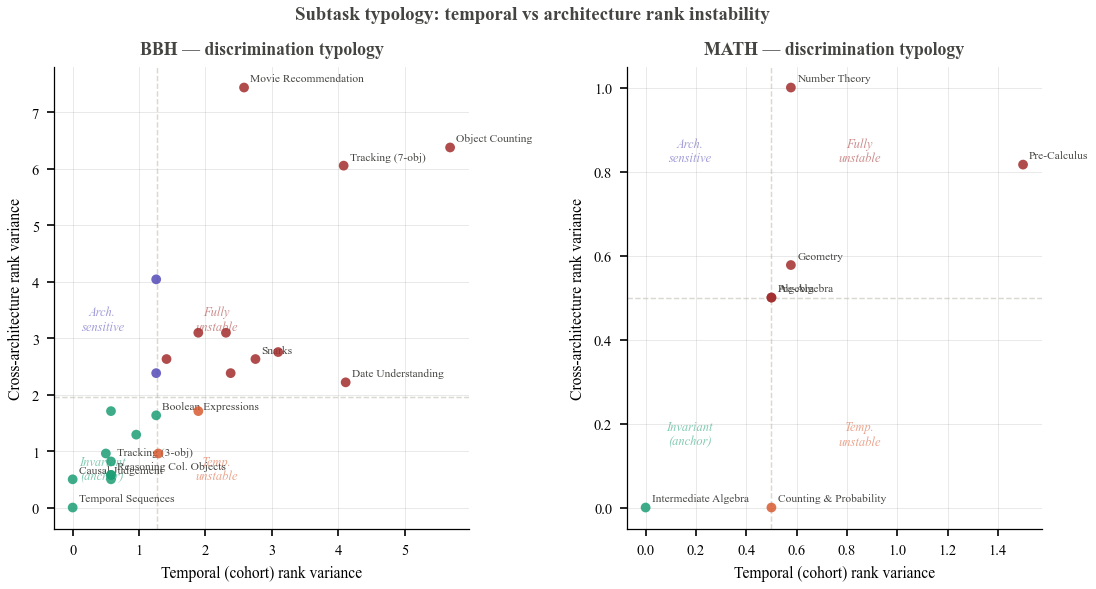

In [31]:
fig4_typology(results, save=False)

## Save All Figures

Re-run all four figures with `save=True` to write publication-quality PDFs to the current directory.

In [ ]:
fig1_rho_heatmaps(results, save=True)
fig2_dendrograms(results, save=True)
fig3_trajectories(data, results, save=True)
fig4_typology(results, save=True)